# Chess Bot
## ♖♘♗♔♕♗♘♖♜♞♝♚♛♝♞♜

## Requirements

In [1]:
!pip install python-chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 76.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=3f6542e851bf2ce6cfa40847709481082485380f68f3bbcff25958d4935b8cb8
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [2]:
import os
from chess import pgn
from tqdm import tqdm
import chess

import numpy as np
from chess import Board
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!apt-get install -y p7zip-full

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [5]:
data_path = '/content/drive/MyDrive/Lichess_data_set/Lichess Elite Database.7z'
!7z x "{data_path}" -o"/content/lichess_elite"


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/Lichess_data_set/                                                  1 file, 610138124 bytes (582 MiB)

Extracting archive: /content/drive/MyDrive/Lichess_data_set/Lichess Elite Database.7z
--
Path = /content/drive/MyDrive/Lichess_data_set/Lichess Elite Database.7z
Type = 7z
Physical Size = 610138124
Headers Size = 1410
Method = LZMA2:24
Solid = +
Blocks = 2

  0%      0% 21 - Lichess Elite Database/lichess_elite_2015-06.pgn                                                            0% 28 - Lichess Elite Data

In [6]:
!ls /content/lichess_elite

'Lichess Elite Database'


In [7]:
!ls "/content/lichess_elite/Lichess Elite Database"

'1 - READ ME.txt'	     lichess_elite_2017-02.pgn
 lichess_elite_2013-09.pgn   lichess_elite_2017-03.pgn
 lichess_elite_2013-11.pgn   lichess_elite_2017-04.pgn
 lichess_elite_2014-01.pgn   lichess_elite_2017-05.pgn
 lichess_elite_2014-02.pgn   lichess_elite_2017-06.pgn
 lichess_elite_2014-03.pgn   lichess_elite_2017-07.pgn
 lichess_elite_2014-04.pgn   lichess_elite_2017-08.pgn
 lichess_elite_2014-05.pgn   lichess_elite_2017-09.pgn
 lichess_elite_2014-06.pgn   lichess_elite_2017-10.pgn
 lichess_elite_2014-07.pgn   lichess_elite_2017-11.pgn
 lichess_elite_2014-08.pgn   lichess_elite_2017-12.pgn
 lichess_elite_2014-09.pgn   lichess_elite_2018-01.pgn
 lichess_elite_2014-10.pgn   lichess_elite_2018-02.pgn
 lichess_elite_2014-11.pgn   lichess_elite_2018-03.pgn
 lichess_elite_2014-12.pgn   lichess_elite_2018-04.pgn
 lichess_elite_2015-01.pgn   lichess_elite_2018-05.pgn
 lichess_elite_2015-02.pgn   lichess_elite_2018-06.pgn
 lichess_elite_2015-03.pgn   lichess_elite_2018-07.pgn
 lichess_elite_2

## Data

In [7]:
files=[file for file in os.listdir("/content/lichess_elite/Lichess Elite Database") if file.endswith(".pgn")]
len(files)

79

## Load Game

In [8]:
def load_pgn(file_path):

    games=[]
    with open(file_path,'r') as pgn_file:
        while True:
            game=pgn.read_game(pgn_file)
            if game is None:
                break
            games.append(game)
    return games



In [9]:
import os
from tqdm import tqdm

pgn_folder = "/content/lichess_elite/Lichess Elite Database"
files = [f for f in os.listdir(pgn_folder) if f.endswith(".pgn")]

# Limit number of files
Limit_of_files = min(len(files), 15)

# Sort files by size
files = sorted(files, key=lambda f: os.path.getsize(os.path.join(pgn_folder, f)))

games = []
i = 1
for file in tqdm(files):
    file_path = os.path.join(pgn_folder, file)
    games.extend(load_pgn(file_path))  # make sure load_pgn() is defined
    if i >= Limit_of_files:
        break
    i += 1

 18%|█▊        | 14/79 [00:06<00:27,  2.32it/s]


In [10]:
len(games)

2394

## Prepration

#### Board to Matrix

In [11]:
def Board_To_Matrix(board:Board):
    matrix = np.zeros((8,8,12))              #12-> ♖♘♗♔♕♗♘♖♜♞♝♚♛♝♞♜
    piece_map = board.piece_map()            #Dictuanry of key->square indesis(63 = h8).  :value->chess.Piece objects (like a white pawn, black rook, etc.)
    #0: Piece.from_symbol('r'),
    #Lowercase = black pieces (r, n, b, q, k, p).
	#Uppercase = white pieces (R, N, B, Q, K, P).
    for square,piece in piece_map.items():
        row,col =divmod(square,8)
        piece_type=piece.piece_type -1
        piece_colour= 0 if piece.color else 6
        matrix[row, col, piece_type+piece_colour]=1
    return matrix


#### Input for Nural Network


In [12]:
def create_input_for_nn (games) :
    x=[]                            # this will collect the position boards of the game from starting to the end of the game
    y=[]                            # the moves which were played (notations to uci) in the uci format
    for game in games:
        board= game.board()
        for move in game.mainline_moves():
            x.append(Board_To_Matrix(board))
            y.append(move.uci())
            board.push(move)
    return x,y


#### Encode Moves

In [13]:
def encode_moves(moves):        # convert moves from uci format to natural numbers
    move_to_int = { move: idx for idx,move in enumerate(set(moves)) }
    return [move_to_int[move] for move in moves],move_to_int
    #       list of moves after maping          ,maping itself

## Nural Network

In [14]:
X,y =create_input_for_nn(games)
y,move_to_int = encode_moves(y)
y =to_categorical(y,num_classes=len(move_to_int))
X =np.array(X)

In [15]:
print(X.shape)
print(y.shape)

(199828, 8, 8, 12)
(199828, 1828)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
)

In [17]:
print(X_train.shape)
print(y_train.shape)

(159862, 8, 8, 12)
(159862, 1828)


In [18]:
print(X_train)


[[[[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 1. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [1. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [1. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [1. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [1. 0. 0. ... 0. 0. 0.]
   [1. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  ...

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 

In [19]:
print(y_train)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [20]:
model=Sequential([
    #Input Layer
    Conv2D(64,(3,3), activation='relu', input_shape=(8,8,12)),
    Conv2D(128,(3,3),activation='relu'),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(len(move_to_int), activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
model.fit(X_train, y_train, epochs=50, validation_split=0.1, batch_size=64)
# model.save("model/chess_model.keras")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 64)       │         6,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1828)           │       469,796 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,075,172 (4.10 MB)

 Trainable params: 1,075,172 (4.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.0427 - loss: 6.3150 - val_accuracy: 0.1090 - val_loss: 5.5739
Epoch 2/50
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1212 - loss: 5.2564 - val_accuracy: 0.1350 - val_loss: 5.0658
Epoch 3/50
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1589 - loss: 4.5696 - val_accuracy: 0.1496 - val_loss: 4.8550
Epoch 4/50
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1933 - loss: 4.0475 - val_accuracy: 0.1529 - val_loss: 4.7938
Epoch 5/50
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2272 - loss: 3.6755 - val_accuracy: 0.1569 - val_loss: 4.8507
Epoch 6/50
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2613 - loss: 3.3699 - val_accuracy: 0.1559 - val_loss: 4.9733
Epoch 7/50
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.2932 - loss: 3.1268 - val_accuracy: 0.1591 - val_loss: 5.1061
Epoch 8/50
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3233 - loss: 2.9060 -

### Save the model

In [22]:
# Save the model as .h5
model.save("/content/my_chess_model_2_75.keras")

In [24]:
from google.colab import files
files.download("/content/my_chess_model_2_75.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### move to int

In [25]:
import pickle

# Save move_to_int dictionary
with open("/content/move_to_int.pkl", "wb") as f:
    pickle.dump(move_to_int, f)

In [26]:
from google.colab import files
files.download("/content/move_to_int.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Load Model

In [ ]:
# Load the trained model
from tensorflow.keras.models import load_model
model = load_model("my_chess_model.h5")

### Load Movr to int

In [ ]:
import pickle

# Load move_to_int dictionary
with open("move_to_int.pkl", "rb") as f:  # Replace with the correct path
    move_to_int = pickle.load(f)

# Optional: check
print(move_to_int)

### Predict

In [23]:

int_to_move = dict(zip(move_to_int.values(), move_to_int.keys()))


def predict_next_move(board):
    board_matrix = Board_To_Matrix(board).reshape(1, 8, 8, 12)
    predictions = model.predict(board_matrix)[0]
    legal_moves = list(board.legal_moves)
    legal_moves_uci = [move.uci() for move in legal_moves]
    sorted_indices = np.argsort(predictions)[::-1]
    for move_index in sorted_indices:
        move = int_to_move[move_index]
        if move in legal_moves_uci:
            return move
    return None

In [41]:
# Create a chess board (start position)
board = Board()

Board before prediction:


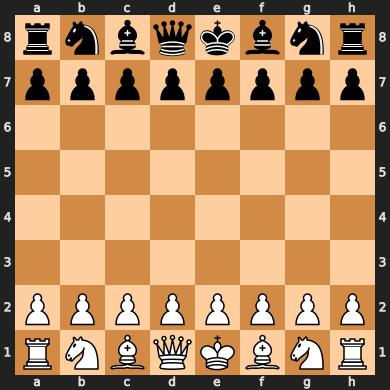

In [42]:
# Display the board before prediction
print("Board before prediction:")
board

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Predicted move: d5a5
Board after prediction:


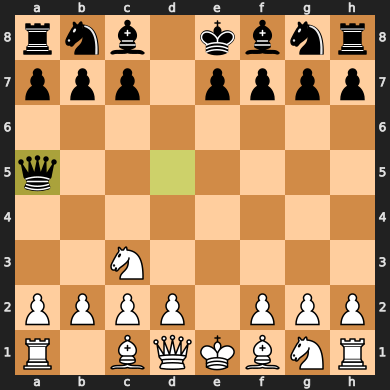

In [48]:


# Predict and make the move
next_move = predict_next_move(board)
board.push_uci(next_move)

# Display the board after prediction
print("\nPredicted move:", next_move)
print("Board after prediction:")
board

In [32]:
print(str(pgn.Game.from_board(board)))

[Event "?"]
[Site "?"]
[Date "????.??.??"]
[Round "?"]
[White "?"]
[Black "?"]
[Result "*"]

1. e4 d5 2. exd5 Qxd5 3. Nc3 Qa5 *
